In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"]="8"
os.environ["OMP_NUM_THREADS"]="1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)
from scipy.spatial.distance import cdist
from scipy.spatial                    import Voronoi, ConvexHull
from scipy.spatial                    import distance as sp_distance
from shapely.geometry                 import Point, Polygon
from sklearn.cluster                  import KMeans

In [3]:


# ----------------------------------------------------
# 1. Read CSV file and apply PCA if needed
# ----------------------------------------------------
def read_points_csv(filename, class_col=None):
    df = pd.read_csv(filename)

    # Select numeric columns
    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    # Remove class column if provided
    if class_col and class_col in numeric_cols:
        numeric_cols.remove(class_col)

    # Apply PCA if dimensions > 2
    if len(numeric_cols) > 2:
        print("Multidimensional data detected → Applying PCA to 2D")
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(df[numeric_cols])
        df["X"] = reduced[:, 0]
        df["Y"] = reduced[:, 1]
        x_col, y_col = "X", "Y"
    else:
        print("2D data detected → PCA not applied")
        x_col, y_col = numeric_cols[0], numeric_cols[1]

    return df, x_col, y_col


# ----------------------------------------------------
# 2. Load Dataset (Unified)
# ----------------------------------------------------
#artificial_dataset_path = '/content/drive/MyDrive/Datasets/Rohan_Datasets/Artificial Datasets/'
#real_dataset_path       = '/content/drive/MyDrive/Datasets/Rohan_Datasets/Real Datasets/'
artificial_dataset_path = 'D:/DataSet/ArtificialDataset/'
real_dataset_path       = 'D:/DataSet/Real Datasets/'

# Change only file name
#file_name = 'S1.csv'
#file_name = 'Aggregation.csv'
#file_name = 'Atom.csv'
#file_name = 'Chainlink.csv'
#file_name = 'Compound.csv'
#file_name = 'D31.csv'
#file_name = 'flame.csv'
#file_name = 'Hepta.csv'
#file_name = 'R15.csv'
#file_name = 'Target.csv'
#file_name = 'iris.csv'
#file_name = 'breast.csv'
#file_name = 'Yeast.csv'
file_name = 'wine.csv'
# Toggle dataset type here
use_artificial = True  # True → Artificial, False → Real

if use_artificial:
    file_path = artificial_dataset_path + file_name
else:
    file_path = real_dataset_path + file_name

# ----------------------------------------------------
# 3. Read + Process
# ----------------------------------------------------
df, x_col, y_col = read_points_csv(file_path, class_col=None)

# Display
display(df)

print(f"X column: {x_col}, Y column: {y_col}")

Multidimensional data detected → Applying PCA to 2D


,Class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,X,Y
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,318.564055,21.490773
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,303.098514,-5.366083
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,438.062063,-6.537986
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,733.240711,0.193320
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,-11.569952,18.487255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,-6.981858,-4.538116
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3.129945,2.338236
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,88.456310,18.779644
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,93.454472,18.674180


X column: X, Y column: Y


In [4]:



# ----------------------------------------------------
# 2. Split region
# ----------------------------------------------------
def split_region(df, x_col, y_col):
    if (df[x_col].max() - df[x_col].min()) > (df[y_col].max() - df[y_col].min()):
        mid = (df[x_col].max() + df[x_col].min()) / 2
        return df[df[x_col] <= mid], df[df[x_col] > mid]
    else:
        mid = (df[y_col].max() + df[y_col].min()) / 2
        return df[df[y_col] <= mid], df[df[y_col] > mid]


# ----------------------------------------------------
# 3. Divide data into k parts
# ----------------------------------------------------
def divide_into_k_parts(df, k, x_col, y_col):
    regions = [df]

    while len(regions) < k:
        regions.sort(key=len, reverse=True)
        largest = regions.pop(0)

        if len(largest) <= 1:
            regions.append(largest)
            break

        p1, p2 = split_region(largest, x_col, y_col)
        if len(p1) == 0 or len(p2) == 0:
            regions.append(largest)
            break

        regions.extend([p1, p2])

    return regions


# ----------------------------------------------------
# 4. Compute average (centroid) of each part
# ----------------------------------------------------
def compute_part_averages(regions, x_col, y_col):
    return np.array([[r[x_col].mean(), r[y_col].mean()] for r in regions])


# ----------------------------------------------------
# ADDED: Compute median of each part
# ----------------------------------------------------
def compute_part_medians(regions, x_col, y_col):
    return np.array([[r[x_col].median(), r[y_col].median()] for r in regions])


# ----------------------------------------------------
# 5. Manual K-Means (Iterative)
# ----------------------------------------------------
def kmeans_iterative(X, k, initial_centroids, max_iter=100, tol=1e-4):
    centroids = initial_centroids.copy()
    for p in range(max_iter):
        distances = cdist(X, centroids)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])

        if np.linalg.norm(new_centroids - centroids) < tol:
            break

        centroids = new_centroids

    print("Iterations:", p)
    return labels, centroids


# ----------------------------------------------------
# 6. Metrics
# ----------------------------------------------------
def evaluate_clustering(X, labels, true_labels, centroids):
    return {
        "SH": silhouette_score(X, labels),
        "DBI": davies_bouldin_score(X, labels),
        "ARI": adjusted_rand_score(true_labels, labels),
        "HM": homogeneity_score(true_labels, labels),
        "CM": completeness_score(true_labels, labels),
        "VM": v_measure_score(true_labels, labels),
        "ED": np.mean(np.min(cdist(X, centroids), axis=1))
    }


# ----------------------------------------------------
# 7. Plot function
# ----------------------------------------------------
def plot_clusters(X, labels, centroids, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=40)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200)

    for i, c in enumerate(centroids):
        plt.text(c[0], c[1], f"C{i+1}", fontsize=12, fontweight="bold")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.grid(True)
    plt.show()



In [5]:

# ─── CELL 6 : ECKM Algorithm ─────────────────────────────────────────────────
def _voronoi_interior_vertices(vor_vertices, hull):
    polygon = Polygon(hull.points[hull.vertices])
    return np.array([v for v in vor_vertices if polygon.contains(Point(v))])


def _build_empty_circles(interior_vertices, P):
    circles = []
    for center in interior_vertices:
        r = float(np.min(sp_distance.cdist([center], P)))
        circles.append((center, r))
    return circles


def _initial_centers_from_circles(sorted_circles, P, K, tol=1e-6):
    seen = {}                                        # ordered-unique via dict
    for center, r in sorted_circles:
        dists = sp_distance.cdist([center], P)[0]
        for pt in P[np.abs(dists - r) < tol]:
            key = tuple(pt)
            if key not in seen:
                seen[key] = None
    pts = np.array(list(seen.keys()))               # (m, 2)
    return pts[:K]

def run_ECKM(data_2d, K):
    hull           = ConvexHull(data_2d)
    vor            = Voronoi(data_2d)
    interior_v     = _voronoi_interior_vertices(vor.vertices, hull)
    circles        = _build_empty_circles(interior_v, data_2d)
    sorted_circles = sorted(circles, key=lambda x: x[1], reverse=True)
    init_centers   = _initial_centers_from_circles(sorted_circles, data_2d, K)

    km = KMeans(n_clusters=K, init=init_centers, n_init=1, random_state=0)
    km.fit(data_2d)
    return km.labels_, km.cluster_centers_, km.n_iter_



Value of k: 3
Total points: 178
Iterations: 10


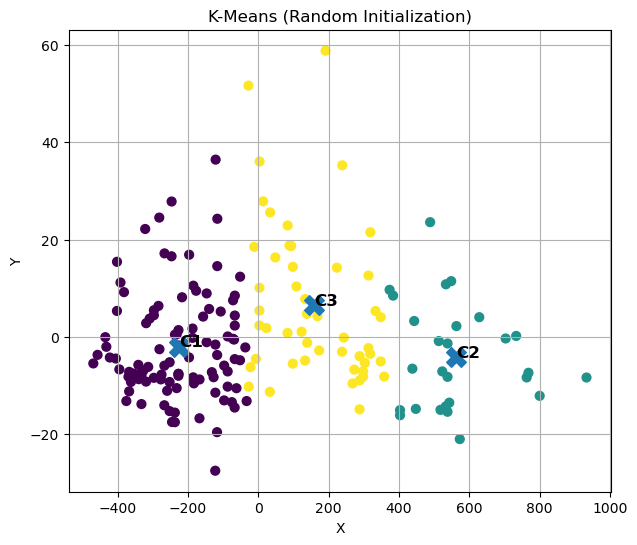

Iterations: 2


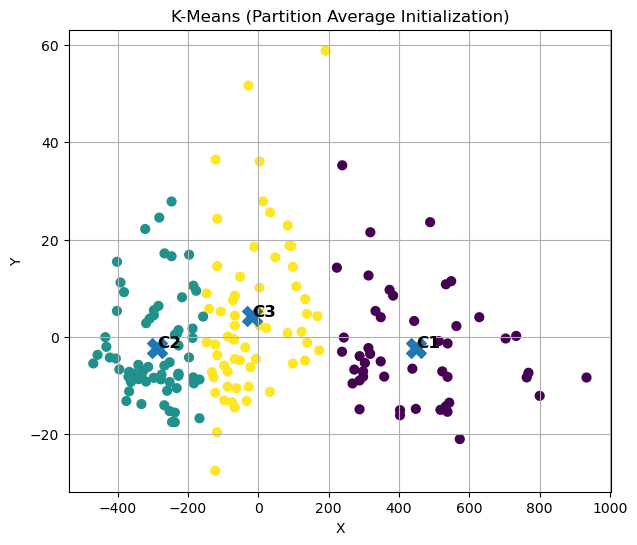

Iterations: 1


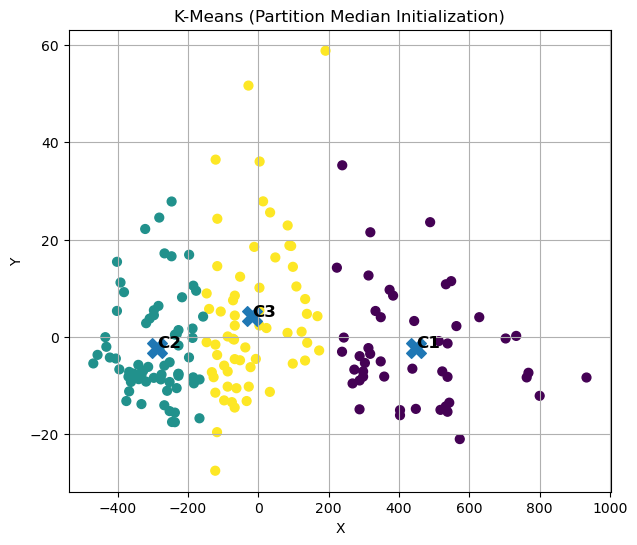

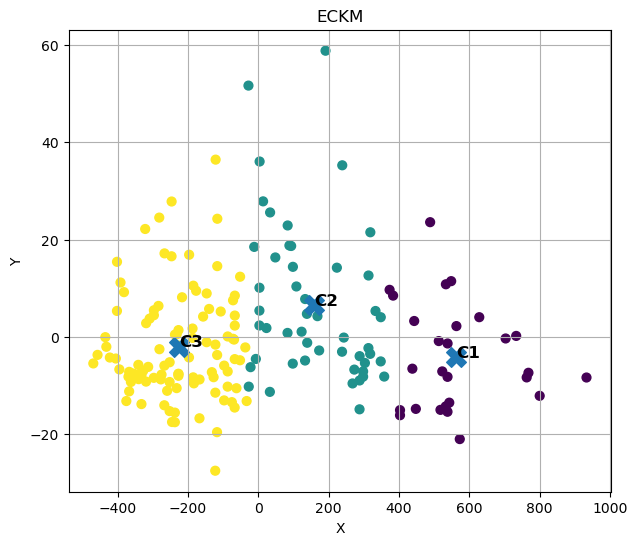

ECKM Iterations: 12

===== PERFORMANCE COMPARISON =====
                                       SH       DBI       ARI        HM  \
KM                               0.560266  0.548732  0.351772  0.398794   
HPKM                             0.572256  0.532968  0.371114  0.428812   
K-Means (Partition Median Init)  0.572256  0.532968  0.371114  0.428812   
ECKM                             0.560266  0.548732  0.351772  0.398794   

                                       CM        VM          ED  Time (s)  
KM                               0.451037  0.423309  103.385693  0.010788  
HPKM                             0.428701  0.428757   92.826283  0.002270  
K-Means (Partition Median Init)  0.428701  0.428757   92.826283  0.001565  
ECKM                             0.451037  0.423309  103.385693  1.055001  


In [6]:

# ----------------------------------------------------
# 8. Main Execution
# ----------------------------------------------------
if __name__ == "__main__":

    # # filename = "Dataset/flame.csv"
    # class_col = "Class"

    # df, x_col, y_col = read_points_csv(filename, class_col)
    class_col = "Class"
    k = df[class_col].nunique()
    X = df[[x_col, y_col]].values
    true_labels = df[class_col].values

    print("\nValue of k:", k)
    print("Total points:", len(df))

    regions = divide_into_k_parts(df, k, x_col, y_col)

    avg_centroids = compute_part_averages(regions, x_col, y_col)
    median_centroids = compute_part_medians(regions, x_col, y_col)

    # -------- K-MEANS (RANDOM INIT) --------
    #np.random.seed(42)
    random_centroids = X[np.random.choice(len(X), k, replace=False)]

    start_rand = time.time()
    labels_rand, centroids_rand = kmeans_iterative(X, k, random_centroids)
    time_rand = time.time() - start_rand

    plot_clusters(X, labels_rand, centroids_rand,
                  "K-Means (Random Initialization)")

    results_rand = evaluate_clustering(X, labels_rand, true_labels, centroids_rand)
    results_rand["Time (s)"] = time_rand

    # -------- K-MEANS (PARTITION AVG INIT) --------
    start_avg = time.time()
    labels_avg, centroids_avg = kmeans_iterative(X, k, avg_centroids)
    time_avg = time.time() - start_avg

    plot_clusters(X, labels_avg, centroids_avg,
                  "K-Means (Partition Average Initialization)")

    results_avg = evaluate_clustering(X, labels_avg, true_labels, centroids_avg)
    results_avg["Time (s)"] = time_avg

    # -------- K-MEANS (PARTITION MEDIAN INIT) --------
    start_med = time.time()
    labels_med, centroids_med = kmeans_iterative(X, k, median_centroids)
    time_med = time.time() - start_med

    plot_clusters(X, labels_med, centroids_med,
                  "K-Means (Partition Median Initialization)")

    results_med = evaluate_clustering(X, labels_med, true_labels, centroids_med)
    results_med["Time (s)"] = time_med

    # -------- ECKM -----------------------------------

    start_eckm = time.time()
    ECKM_labels, ECKM_centroids, ECKM_iters = run_ECKM(X,k)
    plot_clusters(X, ECKM_labels, ECKM_centroids, "ECKM")
    time_eckm = time.time() - start_eckm
    results_eckm= evaluate_clustering(X, ECKM_labels, true_labels, ECKM_centroids)
    results_eckm["Time (s)"] = time_eckm
    print("ECKM Iterations:", ECKM_iters)
    # -------- FINAL COMPARISON --------
    results_df = pd.DataFrame(
        [results_rand, results_avg, results_med,results_eckm],
        index=[
            "KM",
            "HPKM",
            "K-Means (Partition Median Init)",
            "ECKM"
        ]
    )

    print("\n===== PERFORMANCE COMPARISON =====")
    print(results_df)

    #results_df.to_csv("kmeans_iterative_comparison1.csv")
    file_pathe="D:/Project_Kmeans/Barun_Babu/Research Works/2026/HPKM/Result_Met/"
    results_df.to_csv(file_pathe+file_name.replace('.csv','')+"_kmeans_iterative_comparison.csv")

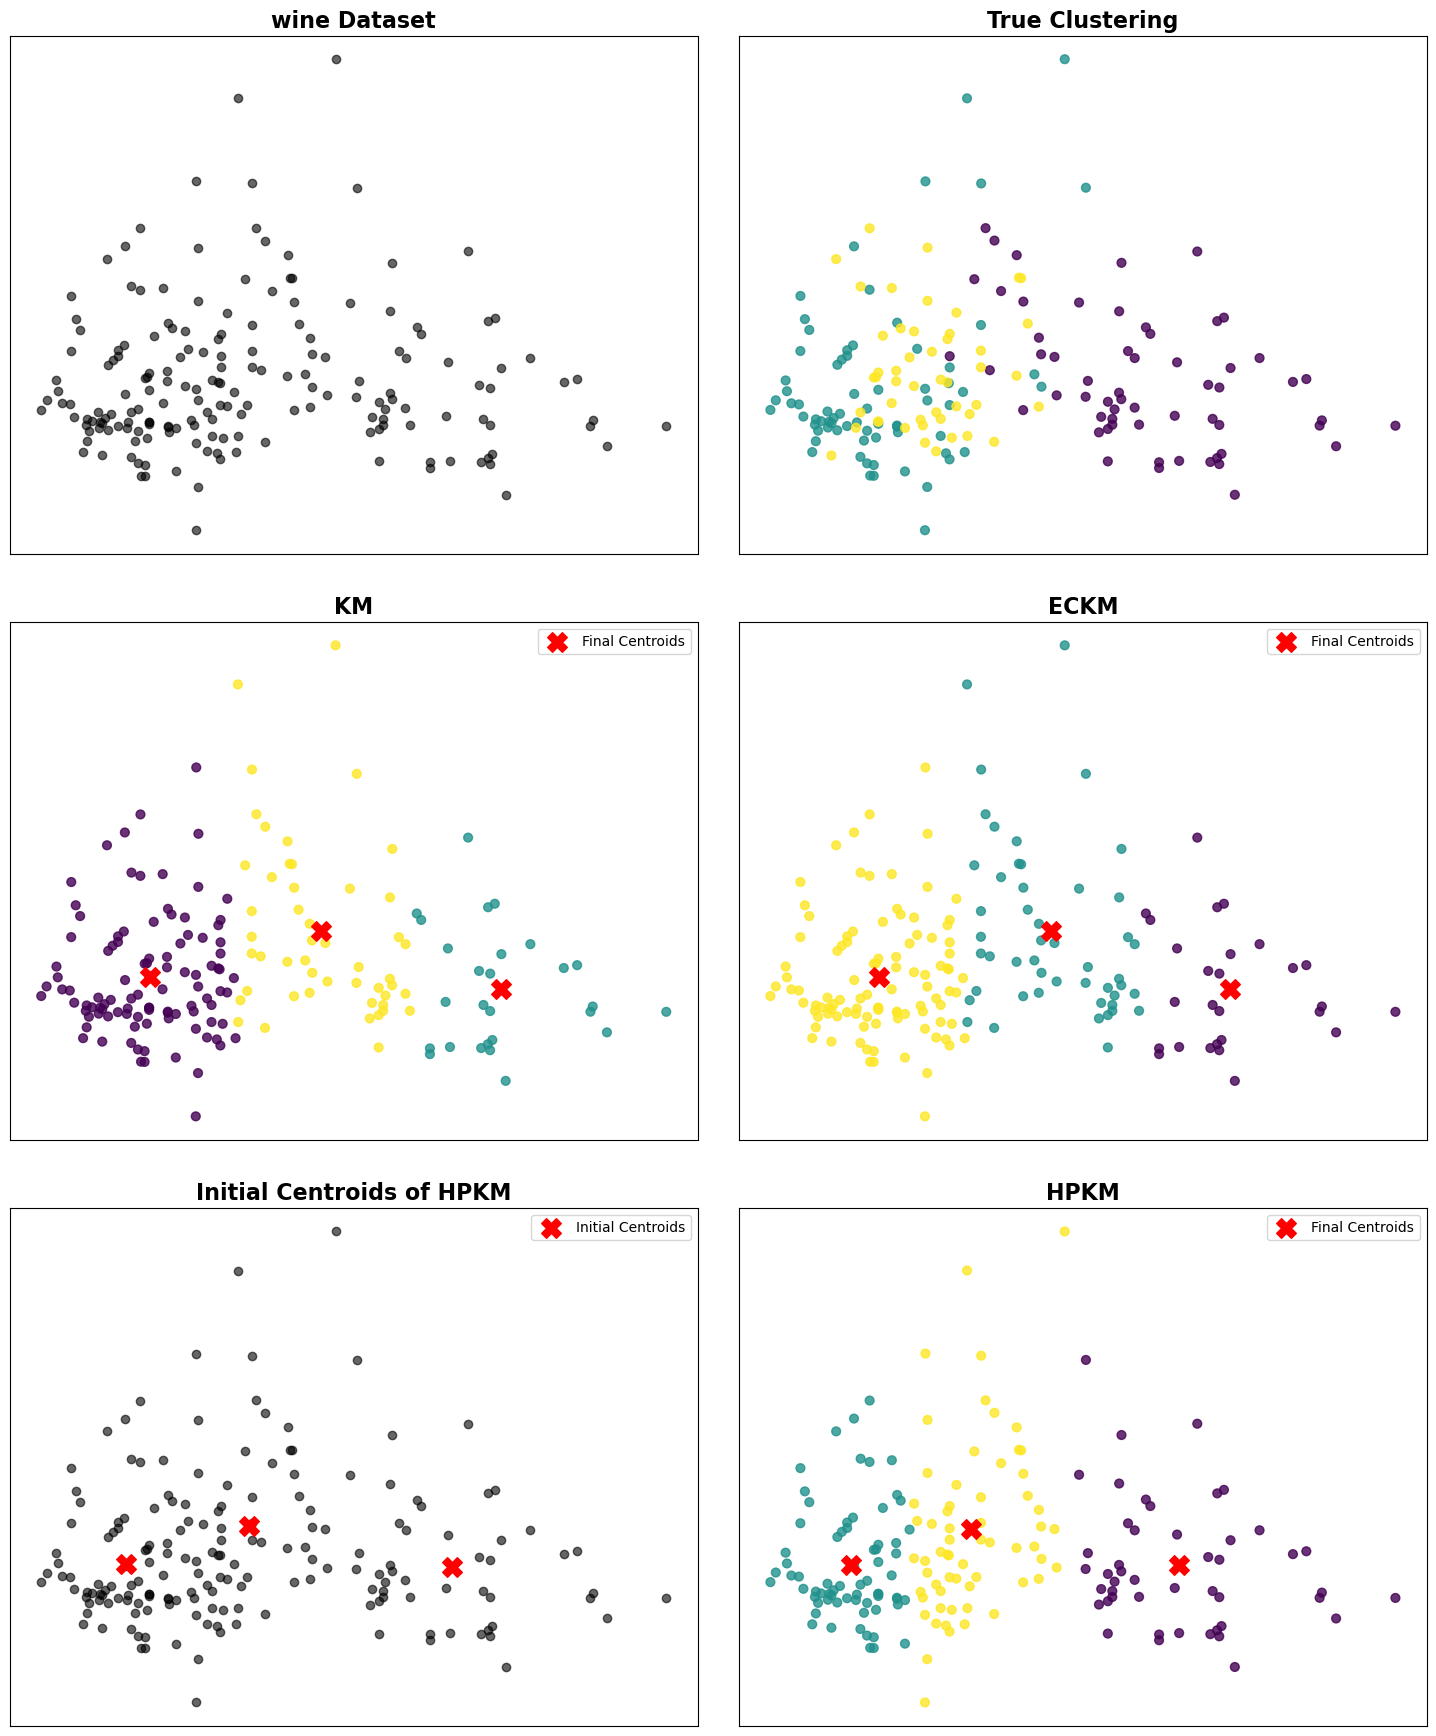

In [7]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os
import numpy as np

# Ensure true_labels are numerical for plotting
if true_labels.dtype == object or true_labels.dtype.kind == 'U': # Check if array contains strings
    le = LabelEncoder()
    numerical_true_labels = le.fit_transform(true_labels)
else:
    numerical_true_labels = true_labels


fig, axs = plt.subplots(3, 2, figsize=(15, 18))
axs = axs.flatten() # Flatten the 2x3 array of axes for easy iteration

# Set a more prominent overall title for the figure
# fig.suptitle('Clustering Results Comparison for S1 Dataset', fontsize=24, fontweight='bold', y=1.02) # Adjust y to move title up a bit
f_n = file_name.replace('.csv','')

# Plot 1: Original Dataset
axs[0].scatter(X[:, 0], X[:, 1], alpha=0.6, c='black')
axs[0].set_title(f'{f_n} Dataset', fontsize=16, fontweight='bold')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
# axs[0].grid(True)

# Plot 2: Initial Centroids of K-Means (Partition Avg Init)
axs[4].scatter(X[:, 0], X[:, 1], alpha=0.6, c='black')
axs[4].scatter(avg_centroids[:, 0], avg_centroids[:, 1], marker='X', s=200, color='red', label='Initial Centroids')
axs[4].set_title('Initial Centroids of HPKM', fontsize=16, fontweight='bold')
axs[4].set_xlabel('X')
axs[4].set_ylabel('Y')
axs[4].legend()
# axs[1].grid(True)

# Plot 3: True Clustering with True Labels   it was 2 became 1
axs[1].scatter(X[:, 0], X[:, 1], c=numerical_true_labels, cmap='viridis', s=40, alpha=0.8)
axs[1].set_title('True Clustering', fontsize=16, fontweight='bold')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
# axs[2].grid(True)

# Plot 4: K-Means (Random Init) Clustering
axs[2].scatter(X[:, 0], X[:, 1], c=labels_rand, cmap='viridis', s=40, alpha=0.8)
axs[2].scatter(centroids_rand[:, 0], centroids_rand[:, 1], marker='X', s=200, color='red', label='Final Centroids')
#axs[2].set_title('K-Means (Random Init)', fontsize=16,fontweight='bold')
axs[2].set_title('KM', fontsize=16,fontweight='bold')
axs[2].set_xlabel('X')
axs[2].set_ylabel('Y')
axs[2].legend()
# axs[2].grid(True)

# Plot 5: ECKM Clustering
axs[3].scatter(X[:, 0], X[:, 1], c=ECKM_labels, cmap='viridis', s=40, alpha=0.8)
axs[3].scatter(ECKM_centroids[:, 0], ECKM_centroids[:, 1], marker='X', s=200, color='red', label='Final Centroids')
axs[3].set_title('ECKM', fontsize=16, fontweight='bold')
axs[3].set_xlabel('X')
axs[3].set_ylabel('Y')
axs[3].legend()
# axs[3].grid(True)

# Plot 6: K-Means (Partition Avg Init) Clustering with Final Centroids
axs[5].scatter(X[:, 0], X[:, 1], c=labels_avg, cmap='viridis', s=40, alpha=0.8)
axs[5].scatter(centroids_avg[:, 0], centroids_avg[:, 1], marker='X', s=200, color='red', label='Final Centroids')
axs[5].set_title('HPKM', fontsize=16, fontweight='bold')
axs[5].set_xlabel('X')
axs[5].set_ylabel('Y')
axs[5].legend()
# axs[5].grid(True)

# Remove x and y axis values from all subplots
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout(pad=3.0) # Added padding to increase space between subplots

#base_path="/content/drive/MyDrive/Research Works/2026/HPKM/Results"
base_path="D:/Project_Kmeans/Barun_Babu/Research Works/2026/HPKM/Result_Img"
output_filename_image = file_name.replace('.csv','') + '_all methods images.png'
full_path = os.path.join(base_path, output_filename_image)
plt.savefig(full_path, dpi=500, bbox_inches='tight')
plt.show()